# Normal Distribution

    A Normal Distribution, also known as a Gaussian Distribution, is a continuous probability distribution in which observations are symmetrically distributed around the mean.

    In a normal distribution, most observations are concentrated near the center of the distribution, while fewer observations occur as the distance from the mean increases.

    The graph of a normal distribution is called the Normal Curve or Bell Curve because of its bell-shaped appearance.

    Many real-world variables approximately follow a normal distribution, making it one of the most important probability distributions in statistics, data analysis, and machine learning.

    Example:-
        - Heights of adults
        - Birth weights of babies
        - IQ scores
        - Blood pressure
        - Measurement errors
    
    Characterstics:-
        - Continuous probability distribution.
        - Bell-shaped curve.
        - Symmetric about the mean.
        - Mean, Median and Mode are equal.
        - Total area under the curve is equal to 1.
        - Half of the observations lie on each side of the mean.
        - The tails extend infinitely without touching the x-axis.
        - The distribution is completely described by its mean and standard deviation.

## Parameters 

### Mean (μ)
    The mean determines the center of the distribution.

    Changing the mean shifts the entire curve left or right without changing its shape.

### Standard Deviation (σ)
    The standard deviation determines the spread of the distribution.

    - Smaller standard deviation → Narrow and taller curve.
    - Larger standard deviation → Wider and flatter curve.


                For every normal distribution,

$$
Mean = Median = Mode
$$

                All three measures of central tendency occur at the center of the distribution.

### Probability Density Function

    The Probability Density Function (PDF) of a normal distribution is

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

                Where,
                    - x = Observation
                    - μ = Mean
                    - σ = Standard Deviation
                    - π = 3.14159
                    - e = Euler's Number (≈2.718)

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as sts

In [2]:
np.random.seed(42)

Scores = pd.DataFrame({

    "Exam_Score": np.random.normal(
        loc=70,
        scale=10,
        size=500
    )

})

Scores.head()

,Exam_Score
0,74.967142
1,68.617357
2,76.476885
3,85.230299
4,67.658466


In [3]:
Scores.describe().round(2)

,Exam_Score
count,500.00
mean,70.07
std,9.81
min,37.59
25%,63.00
50%,70.13
75%,76.37
max,108.53


In [4]:
mean = Scores["Exam_Score"].mean()

median = Scores["Exam_Score"].median()

mode = Scores["Exam_Score"].mode()[0]

std = Scores["Exam_Score"].std()

print(f"Mean   : {mean:.2f}")

print(f"Median : {median:.2f}")

print(f"Mode   : {mode:.2f}")

print(f"Standard Deviation : {std:.2f}")

Mean   : 70.07
Median : 70.13
Mode   : 37.59
Standard Deviation : 9.81


### Area Under the Normal Curve
    The area under the normal curve represents probability.

        The total area under the curve is always equal to 1.
        This means
                        P(X)=1  or \100\%

    Since the distribution is symmetric,
        - Area to the left of the mean = 0.5
        - Area to the right of the mean = 0.5

        Therefore,

$$
P(X<\mu)=0.5
$$

$$
P(X>\mu)=0.5
$$

### Empirical Rule (68–95–99.7 Rule)

    The Empirical Rule describes how observations are distributed around the mean in a Normal Distribution.

    Approximately,
        - 68% of observations lie within one standard deviation from the mean.
        - 95% of observations lie within two standard deviations from the mean.
        - 99.7% of observations lie within three standard deviations from the mean.

    This rule is also known as the Three Sigma Rule.

In [5]:
mean = Scores["Exam_Score"].mean()

std = Scores["Exam_Score"].std()

print(f"Mean : {mean:.2f}")

print(f"Standard Deviation : {std:.2f}")

Mean : 70.07
Standard Deviation : 9.81


In [6]:
lower1 = mean - std
upper1 = mean + std

lower2 = mean - 2*std
upper2 = mean + 2*std

lower3 = mean - 3*std
upper3 = mean + 3*std

print(f"μ ± 1σ : {lower1:.2f} to {upper1:.2f}")

print(f"μ ± 2σ : {lower2:.2f} to {upper2:.2f}")

print(f"μ ± 3σ : {lower3:.2f} to {upper3:.2f}")

μ ± 1σ : 60.26 to 79.88
μ ± 2σ : 50.44 to 89.69
μ ± 3σ : 40.63 to 99.51


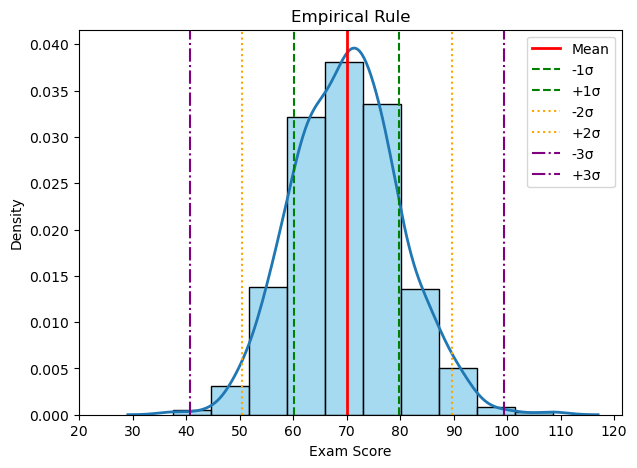

In [25]:
plt.figure(figsize=(7,5))

sns.histplot(
    Scores["Exam_Score"],
    bins=10,
    stat="density",
    color="skyblue",
    edgecolor="black"
)

sns.kdeplot(
    Scores["Exam_Score"],
    linewidth=2
)

plt.axvline(mean,color="red",linewidth=2,label="Mean")

plt.axvline(lower1,color="green",linestyle="--",label='-1σ')
plt.axvline(upper1,color="green",linestyle="--",label='+1σ')

plt.axvline(lower2,color="orange",linestyle=":",label='-2σ')
plt.axvline(upper2,color="orange",linestyle=":",label='+2σ')

plt.axvline(lower3,color="purple",linestyle="-.",label='-3σ')
plt.axvline(upper3,color="purple",linestyle="-.",label='+3σ')

plt.title("Empirical Rule")

plt.xlabel("Exam Score")

plt.ylabel("Density")

plt.xticks(np.arange(20, 121, 10))

plt.legend()

plt.show()

In [16]:
within1 = ((Scores["Exam_Score"] >= lower1) &
           (Scores["Exam_Score"] <= upper1)).mean()*100

within2 = ((Scores["Exam_Score"] >= lower2) &
           (Scores["Exam_Score"] <= upper2)).mean()*100

within3 = ((Scores["Exam_Score"] >= lower3) &
           (Scores["Exam_Score"] <= upper3)).mean()*100

print(f"Within 1σ : {within1:.2f}%")

print(f"Within 2σ : {within2:.2f}%")

print(f"Within 3σ : {within3:.2f}%")

Within 1σ : 69.80%
Within 2σ : 95.60%
Within 3σ : 99.40%


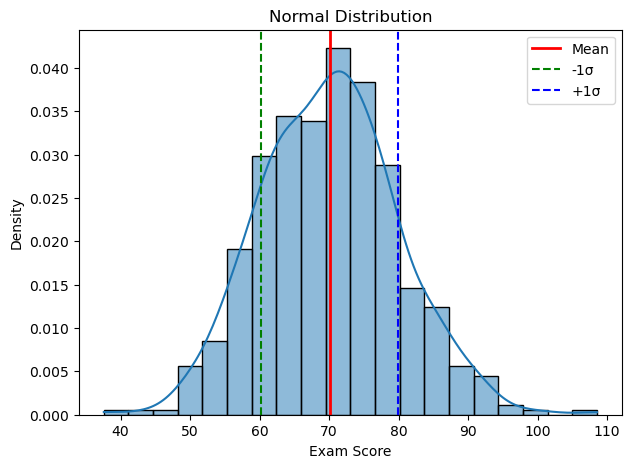

In [10]:
plt.figure(figsize=(7,5))

sns.histplot(
    Scores["Exam_Score"],
    bins=20,
    stat="density",
    kde=True,
    edgecolor="black"
)

plt.axvline(mean, color="red", linewidth=2, label="Mean")

plt.axvline(lower1, color="green", linestyle="--", label="-1σ")
plt.axvline(upper1, color="blue", linestyle="--", label="+1σ")

plt.title("Normal Distribution")

plt.xlabel("Exam Score")

plt.ylabel("Density")

plt.legend()

plt.show()

# Standard Normal Distribution
    A Standard Normal Distribution, also called the Z-Distribution, is a special type of normal distribution in which the mean is equal to 0 and the standard deviation is equal to 1.

    It is obtained by transforming a normal distribution into a common scale using the Z-Score.

    Standardizing data allows observations from different datasets to be compared on the same scale.

    Characterstics:-
        - Mean = 0
        - Standard Deviation = 1
        - Bell-shaped curve
        - Symmetric about zero
        - Total area under the curve is equal to 1
        - Half of the observations lie on each side of zero

### Z-Score
    A Z-Score represents the number of standard deviations an observation is away from the mean.

    It measures the relative position of an observation within a distribution.

## Formula
                    The Z-Score is calculated using

$$
Z=\frac{X-\mu}{\sigma}
$$

                    Where,
                        - X = Observation
                        - μ = Mean
                        - σ = Standard Deviation
                        - Z = Standard Score  
| Z-Score | Interpretation |
|---------:|----------------|
| Z = 0 | Observation is exactly at the mean |
| Z > 0 | Observation is above the mean |
| Z < 0 | Observation is below the mean |
| Z = 1 | One standard deviation above the mean |
| Z = -1 | One standard deviation below the mean |
| \|Z\| > 3 | Possible Outlier |

### Manual Example
    Mean Exam Score = 70
    Standard Deviation = 10
    Student Score = 85

    Using the formula,
$$
Z=\frac{85-70}{10}=1.5
$$

    The student's score is 1.5 standard deviations above the mean .

In [26]:
mean = Scores["Exam_Score"].mean()

std = Scores["Exam_Score"].std()

Scores["Z_Score"] = (Scores["Exam_Score"] - mean) / std

Scores.head()

,Exam_Score,Z_Score
0,74.967142,0.499235
1,68.617357,-0.147874
2,76.476885,0.653094
3,85.230299,1.545159
4,67.658466,-0.245595


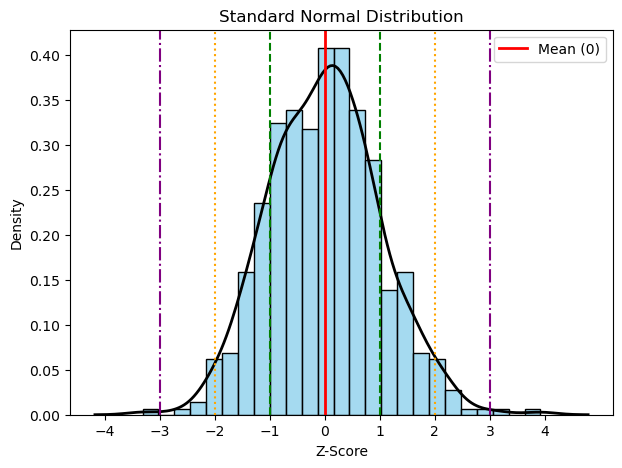

In [32]:
plt.figure(figsize=(7,5))

sns.histplot(
    Scores["Z_Score"],
    bins=25,
    stat="density",
    color="skyblue",
    edgecolor="black"
)

sns.kdeplot(
    Scores["Z_Score"],
    linewidth=2,
    color='black'
)

plt.axvline(0, color="red", linewidth=2, label="Mean (0)")

plt.axvline(-1, color="green", linestyle="--")
plt.axvline(1, color="green", linestyle="--")

plt.axvline(-2, color="orange", linestyle=":")
plt.axvline(2, color="orange", linestyle=":")

plt.axvline(-3, color="purple", linestyle="-.")
plt.axvline(3, color="purple", linestyle="-.")

plt.xticks(np.arange(-4,5,1))

plt.title("Standard Normal Distribution")

plt.xlabel("Z-Score")

plt.ylabel("Density")

plt.legend()

plt.show()